<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab3_2_statistics_optimization_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadística y Optimización en Python
## Ciencia de Datos Ambientales – Aplicado al Perú

**Objetivos de aprendizaje:**
- Realizar análisis estadístico con SciPy
- Ejecutar pruebas de hipótesis (t-test, correlación)
- Comprender y ajustar distribuciones de probabilidad
- Definir funciones de costo y realizar optimización

**Entorno:** Este notebook está diseñado para ejecutarse en Google Colab.

---

In [ ]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize, curve_fit

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Repaso: Estadística Descriptiva con Pandas

Repasemos el cálculo de estadísticas básicas antes de pasar a la estadística inferencial.
Usaremos datos de inventario forestal de dos tipos de bosque peruano:
**bosque amazónico de tierra firme** (Madre de Dios) y **bosque andino de neblina** (Junín).

In [ ]:
# Datos ambientales de muestra: mediciones de árboles en dos tipos de bosque peruano
np.random.seed(42)

# Simular mediciones de DAP (cm) para dos tipos de bosque
# Bosque amazónico (Madre de Dios): árboles más grandes en promedio
dap_amazonia = np.random.normal(loc=35, scale=8, size=30)
# Bosque andino de neblina (Junín): árboles más pequeños
dap_andino   = np.random.normal(loc=32, scale=10,  size=25)

# Crear DataFrame
arboles_df = pd.DataFrame({
    'dap_cm': np.concatenate([dap_amazonia, dap_andino]),
    'tipo_bosque': ['Amazónico (MDD)']*30 + ['Andino-Neblina (JUN)']*25
})

print(f"Total de árboles: {len(arboles_df)}")
arboles_df.head()

Total de árboles: 55


,dap_cm,tipo_bosque
0,38.973713,Amazónico (MDD)
1,33.893886,Amazónico (MDD)
2,40.181508,Amazónico (MDD)
3,47.184239,Amazónico (MDD)
4,33.126773,Amazónico (MDD)


In [ ]:
# Estadísticas descriptivas por grupo
arboles_df.groupby('tipo_bosque')['dap_cm'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tipo_bosque,,,,,,,,
Amazónico (MDD),300.0,34.96,7.87,9.07,29.53,35.47,40.01,65.82
Andino-Neblina (JUN),250.0,31.69,9.69,7.28,24.38,31.73,38.21,62.79


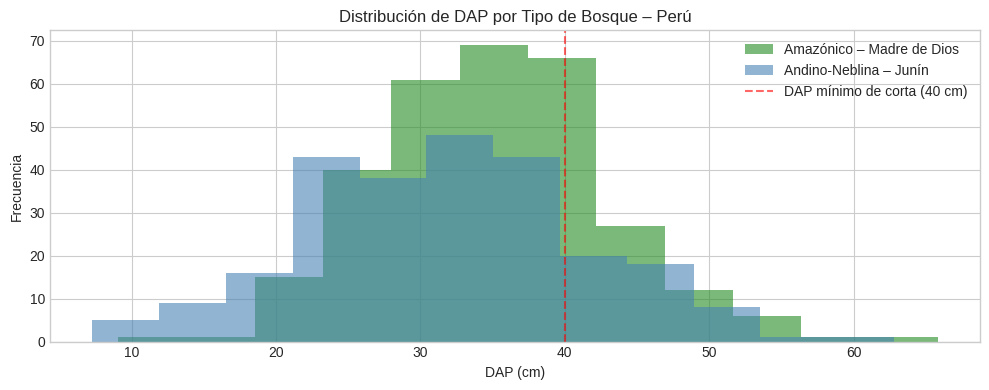

In [ ]:
# Visualizar las distribuciones
fig, ax = plt.subplots(figsize=(10, 4))

arboles_df[arboles_df['tipo_bosque'] == 'Amazónico (MDD)']['dap_cm'].hist(
    alpha=0.6, label='Amazónico – Madre de Dios', bins=12, ax=ax, color='forestgreen')
arboles_df[arboles_df['tipo_bosque'] == 'Andino-Neblina (JUN)']['dap_cm'].hist(
    alpha=0.6, label='Andino-Neblina – Junín', bins=12, ax=ax, color='steelblue')

ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='DAP mínimo de corta (40 cm)')
ax.set_xlabel('DAP (cm)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de DAP por Tipo de Bosque – Perú')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Introducción a las Distribuciones con SciPy

El módulo `stats` de SciPy ofrece un amplio conjunto de funciones estadísticas:
- Distribuciones de probabilidad
- Pruebas estadísticas
- Estadísticas descriptivas

### 2.1 Trabajando con distribuciones

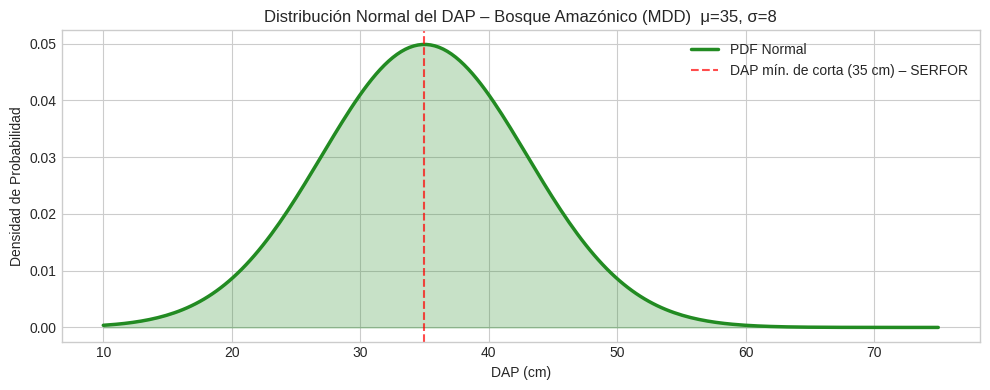

In [ ]:
# Distribución normal

# Distribución normal aplicada al DAP del bosque amazónico
# Parámetros: media = 35 cm, desviación estándar = 8 cm
dist_amazonia = stats.norm(loc=35, scale=8)

# PDF (Función de Densidad de Probabilidad) – altura de la curva
x = np.linspace(10, 75, 200)
valores_pdf = dist_amazonia.pdf(x)

plt.figure(figsize=(10, 4))
plt.plot(x, valores_pdf, 'forestgreen', linewidth=2.5, label='PDF Normal')
plt.fill_between(x, valores_pdf, alpha=0.25, color='forestgreen')
plt.axvline(35, color='red', linestyle='--', alpha=0.7,
            label='DAP mín. de corta (35 cm) – SERFOR')
plt.xlabel('DAP (cm)')
plt.ylabel('Densidad de Probabilidad')
plt.title('Distribución Normal del DAP – Bosque Amazónico (MDD)  μ=35, σ=8')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# CDF (Función de Distribución Acumulada) – P(X ≤ x)
# ¿Qué proporción de árboles tiene DAP ≤ 40 cm? (por debajo del mínimo de corta)
prob_menor_40 = dist_amazonia.cdf(40)
print(f"P(DAP ≤ 40 cm) = {prob_menor_40:.3f}  →  {prob_menor_40*100:.1f}% de árboles bajo el DAP mínimo")

# Probabilidad de que un árbol tenga DAP entre 40 y 60 cm (rango de aprovechamiento)
prob_40_60 = dist_amazonia.cdf(60) - dist_amazonia.cdf(40)
print(f"P(40 < DAP ≤ 60 cm) = {prob_40_60:.3f}  →  rango de aprovechamiento forestal")

P(DAP ≤ 40 cm) = 0.734  →  73.4% de árboles bajo el DAP mínimo
P(40 < DAP ≤ 60 cm) = 0.265  →  rango de aprovechamiento forestal


In [ ]:
# PPF (Función Percentil) – inversa de la CDF
# ¿Qué valor de DAP corresponde al percentil 95?
dap_p95 = dist_amazonia.ppf(0.95)
print(f"Percentil 95 del DAP: {dap_p95:.1f} cm  (árboles emergentes más grandes)")

# Rango central del 90% de los árboles
limite_inf = dist_amazonia.ppf(0.05)
limite_sup = dist_amazonia.ppf(0.95)
print(f"Rango del 90% central de los árboles: {limite_inf:.1f} – {limite_sup:.1f} cm")

Percentil 95 del DAP: 48.2 cm  (árboles emergentes más grandes)
Rango del 90% central de los árboles: 21.8 – 48.2 cm


In [ ]:
# Generar muestras aleatorias de una distribución (útil para simulación Monte Carlo)
muestras = dist_amazonia.rvs(size=1000)
print(f"Media de la muestra:  {np.mean(muestras):.2f} cm")
print(f"Desv. est. de la muestra: {np.std(muestras):.2f} cm")

Media de la muestra:  34.75 cm
Desv. est. de la muestra: 7.97 cm


### 2.2 Ajustando distribuciones a los datos

In [ ]:
# Ajustar una distribución normal a los datos reales de DAP amazónico
datos_amazonia = arboles_df[arboles_df['tipo_bosque'] == 'Amazónico (MDD)']['dap_cm']

# fit() devuelve los parámetros que mejor describen los datos
mu, sigma = stats.norm.fit(datos_amazonia)
print(f"Parámetros ajustados: μ = {mu:.2f} cm,  σ = {sigma:.2f} cm")

Parámetros ajustados: μ = 33.49 cm,  σ = 7.08 cm


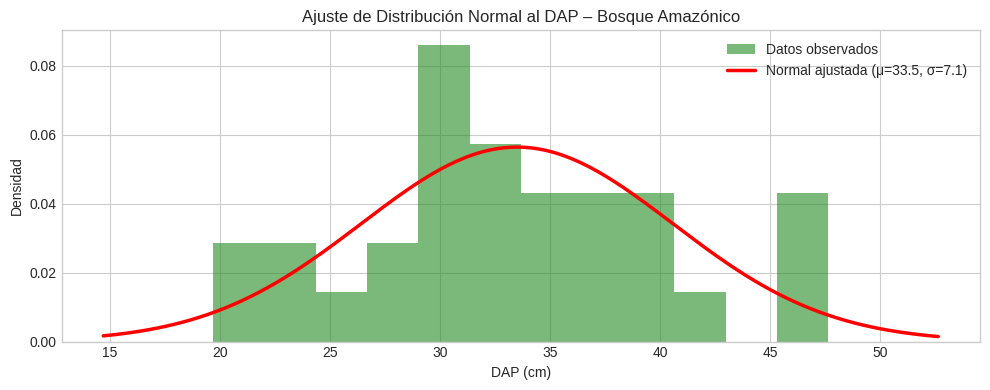

In [ ]:
# Visualizar el ajuste
fig, ax = plt.subplots(figsize=(10, 4))

# Histograma de datos reales (normalizado para mostrar densidad)
ax.hist(datos_amazonia, bins=12, density=True, alpha=0.6,
        color='forestgreen', label='Datos observados')

# Distribución ajustada
x = np.linspace(datos_amazonia.min() - 5, datos_amazonia.max() + 5, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2.5,
        label=f'Normal ajustada (μ={mu:.1f}, σ={sigma:.1f})')

ax.set_xlabel('DAP (cm)')
ax.set_ylabel('Densidad')
ax.set_title('Ajuste de Distribución Normal al DAP – Bosque Amazónico')
ax.legend()
plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 1 – Distribuciones

El SENAMHI reporta que la precipitación anual en Iquitos sigue una distribución normal con **media = 2890 mm** y **desviación estándar = 210 mm**.

1. Crea la distribución normal con esos parámetros
2. ¿Cuál es la probabilidad de que un año tenga precipitación **menor a 2500 mm** (año seco severo)?
3. ¿Qué nivel de precipitación corresponde al percentil 10? (umbral de sequía)
4. ¿Entre qué valores se encuentra el 80% central de las precipitaciones anuales?

In [ ]:
# Tu código aquí
# dist_precip = stats.norm(loc=???, scale=???)

# prob_seco = ???
# umbral_sequia = ???
# limite_inf_80 = ???
# limite_sup_80 = ???

---
## 3. Pruebas de Hipótesis

Las pruebas estadísticas nos permiten hacer inferencias sobre poblaciones a partir de muestras de datos.

### 3.1 Prueba t de una muestra

**Pregunta:** ¿El DAP medio del bosque amazónico de Madre de Dios es significativamente diferente de 30 cm (umbral mínimo de corta establecido por el SERFOR)?

In [ ]:
# Prueba t de una muestra
# H0: μ = 30 cm  (el DAP medio coincide con el mínimo de corta)
# H1: μ ≠ 30 cm  (el DAP medio es diferente)

datos_amazonia = arboles_df[arboles_df['tipo_bosque'] == 'Amazónico (MDD)']['dap_cm']

t_stat, p_valor = stats.ttest_1samp(datos_amazonia, popmean=30)

print(f"Media muestral:  {datos_amazonia.mean():.2f} cm")
print(f"Estadístico t:   {t_stat:.3f}")
print(f"Valor p:         {p_valor:.4f}")

alpha = 0.05
if p_valor < alpha:
    print(f"\nConclusión: Se rechaza H0 (p < {alpha})")
    print("El DAP medio del bosque amazónico es significativamente diferente de 30 cm.")
else:
    print(f"\nConclusión: No se rechaza H0 (p ≥ {alpha})")
    print("No hay evidencia suficiente de diferencia respecto a 30 cm.")

Media muestral:  33.49 cm
Estadístico t:   2.659
Valor p:         0.0126

Conclusión: Se rechaza H0 (p < 0.05)
El DAP medio del bosque amazónico es significativamente diferente de 30 cm.


### 3.2 Prueba t de dos muestras (muestras independientes)

**Pregunta:** ¿Existe una diferencia significativa en el DAP medio entre el bosque amazónico y el bosque andino de neblina?

In [ ]:
# Prueba t de dos muestras independientes
# H0: μ_amazónico = μ_andino
# H1: μ_amazónico ≠ μ_andino

datos_amazonia = arboles_df[arboles_df['tipo_bosque'] == 'Amazónico (MDD)']['dap_cm']
datos_andino   = arboles_df[arboles_df['tipo_bosque'] == 'Andino-Neblina (JUN)']['dap_cm']

t_stat, p_valor = stats.ttest_ind(datos_amazonia, datos_andino)

print(f"DAP medio – Amazónico:    {datos_amazonia.mean():.2f} cm  (n={len(datos_amazonia)})")
print(f"DAP medio – Andino:       {datos_andino.mean():.2f} cm  (n={len(datos_andino)})")
print(f"\nEstadístico t:  {t_stat:.3f}")
print(f"Valor p:        {p_valor:.4f}")

alpha = 0.05
if p_valor < alpha:
    print(f"\nConclusión: Diferencia significativa entre tipos de bosque (p < {alpha})")
    print("El bosque amazónico tiene árboles significativamente más gruesos.")
else:
    print(f"\nConclusión: Sin diferencia significativa (p ≥ {alpha})")

DAP medio – Amazónico:    33.49 cm  (n=30)
DAP medio – Andino:       30.11 cm  (n=25)

Estadístico t:  1.496
Valor p:        0.1406

Conclusión: Sin diferencia significativa (p ≥ 0.05)


### 🔬 Ejercicio rápido 2 – Prueba t

El INAIGEM mide el pH del agua en dos cuencas andinas:
- **Cuenca del Mantaro**: pH registrados → `[6.8, 7.2, 6.5, 7.0, 6.9, 7.3, 6.7, 7.1]`
- **Cuenca del Rímac**: pH registrados → `[6.1, 5.9, 6.4, 6.0, 6.3, 5.8, 6.2, 6.1]`

El ECA-MINAM para agua de categoría 1 establece un pH mínimo de 6.5.

1. Realiza una **prueba t de una muestra** para el Rímac: ¿su pH medio es significativamente menor que 6.5?
2. Realiza una **prueba t de dos muestras**: ¿hay diferencia significativa entre las dos cuencas?
3. Interpreta los resultados en términos ambientales.

In [ ]:
# Tu código aquí
ph_mantaro = np.array([6.8, 7.2, 6.5, 7.0, 6.9, 7.3, 6.7, 7.1])
ph_rimac   = np.array([6.1, 5.9, 6.4, 6.0, 6.3, 5.8, 6.2, 6.1])

# t_stat_1, p_1 = stats.ttest_1samp(???)
# t_stat_2, p_2 = stats.ttest_ind(???)

### 3.3 Análisis de correlación

**Pregunta:** ¿Existe relación entre el DAP y la altura de los árboles en el inventario forestal de Madre de Dios?

In [ ]:
# Crear datos correlacionados DAP–Altura para árboles amazónicos
np.random.seed(42)
n = 50
dap  = np.random.uniform(20, 70, n)
# La altura aumenta con el DAP más un término de ruido
altura = 0.45 * dap + np.random.normal(0, 3.5, n) + 8

mediciones = pd.DataFrame({'dap_cm': dap, 'altura_m': altura})
mediciones.head()

,dap_cm,altura_m
0,38.727006,28.011786
1,67.535715,38.990861
2,56.599697,33.065095
3,49.932924,29.415953
4,27.800932,15.335592


In [ ]:
# Coeficiente de correlación de Pearson
r, p_valor = stats.pearsonr(mediciones['dap_cm'], mediciones['altura_m'])

print(f"Pearson r:  {r:.3f}")
print(f"Valor p:    {p_valor:.6f}")

# Interpretar la correlación
fuerza    = "fuerte" if abs(r) > 0.7 else ("moderada" if abs(r) > 0.4 else "débil")
direccion = "positiva" if r > 0 else "negativa"
print(f"\nInterpretación: correlación {fuerza} {direccion}")
print(f"El DAP explica aproximadamente el {r**2*100:.1f}% de la varianza en la altura.")

Pearson r:  0.890
Valor p:    0.000000

Interpretación: correlación fuerte positiva
El DAP explica aproximadamente el 79.3% de la varianza en la altura.


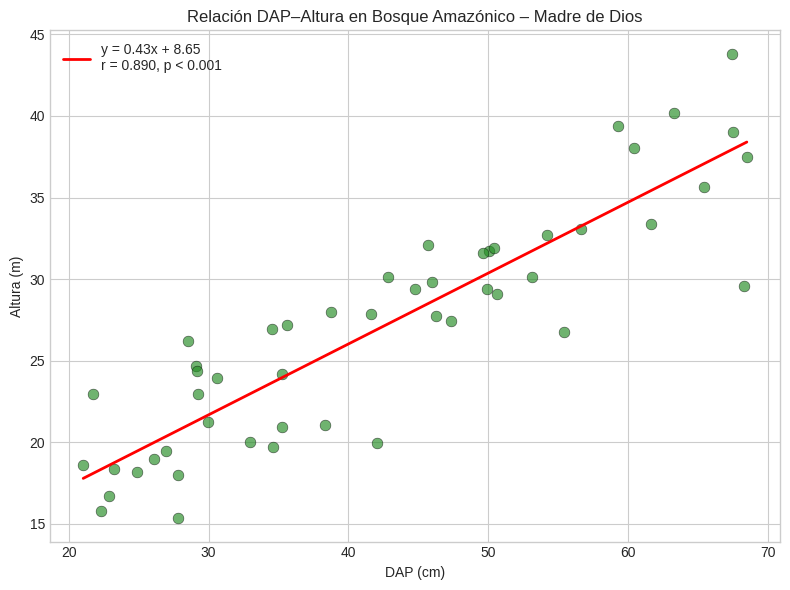

In [ ]:
# Visualizar la correlación con línea de regresión
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(mediciones['dap_cm'], mediciones['altura_m'],
           alpha=0.65, edgecolors='black', linewidth=0.4, color='forestgreen', s=60)

# Línea de regresión
pendiente, intercepto, r_val, p_val, err_est = stats.linregress(
    mediciones['dap_cm'], mediciones['altura_m'])

x_linea = np.array([dap.min(), dap.max()])
y_linea  = pendiente * x_linea + intercepto
ax.plot(x_linea, y_linea, 'r-', linewidth=2,
        label=f'y = {pendiente:.2f}x + {intercepto:.2f}\nr = {r:.3f}, p < 0.001')

ax.set_xlabel('DAP (cm)')
ax.set_ylabel('Altura (m)')
ax.set_title('Relación DAP–Altura en Bosque Amazónico – Madre de Dios')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 Pruebas no paramétricas

Cuando los datos no cumplen los supuestos de normalidad, se usan alternativas no paramétricas. Son comunes en datos ecológicos con distribuciones sesgadas (ej. abundancia de especies).

In [ ]:
# Prueba de Mann-Whitney U (alternativa no paramétrica a la prueba t)
# Útil para datos de abundancia de especies, índices de diversidad, etc.
stat, p_valor = stats.mannwhitneyu(datos_amazonia, datos_andino,
                                    alternative='two-sided')

print("Prueba de Mann-Whitney U")
print(f"Estadístico U:  {stat:.1f}")
print(f"Valor p:        {p_valor:.4f}")
print("(Alternativa no paramétrica para comparar dos grupos independientes)")

Prueba de Mann-Whitney U
Estadístico U:  444.0
Valor p:        0.2469
(Alternativa no paramétrica para comparar dos grupos independientes)


In [ ]:
# Correlación de Spearman (basada en rangos, no paramétrica)
# Robusta ante valores atípicos y relaciones monótonas no lineales
rho, p_valor = stats.spearmanr(mediciones['dap_cm'], mediciones['altura_m'])

print(f"Spearman ρ:  {rho:.3f}")
print(f"Valor p:     {p_valor:.6f}")
print("(Mide la monotonía de la relación, sin asumir linealidad)")

Spearman ρ:  0.896
Valor p:     0.000000
(Mide la monotonía de la relación, sin asumir linealidad)


In [ ]:
# Prueba de normalidad – Shapiro-Wilk
# Útil para verificar el supuesto de normalidad antes de usar pruebas paramétricas
stat_sw, p_sw = stats.shapiro(datos_amazonia)
print(f"Prueba de Shapiro-Wilk para DAP amazónico:")
print(f"  Estadístico W = {stat_sw:.4f}")
print(f"  Valor p = {p_sw:.4f}")
if p_sw > 0.05:
    print("  → No se rechaza H0: los datos son compatibles con normalidad (p > 0.05)")
else:
    print("  → Se rechaza H0: los datos no son normales (p < 0.05)")

Prueba de Shapiro-Wilk para DAP amazónico:
  Estadístico W = 0.9751
  Valor p = 0.6868
  → No se rechaza H0: los datos son compatibles con normalidad (p > 0.05)


### 🔬 Ejercicio rápido 3 – Correlación

El equipo del SERNANP registra el NDVI y la precipitación acumulada mensual en 10 sitios de monitoreo del Parque Nacional Manu:

```python
precip_mm = np.array([185, 210, 320, 410, 480, 290, 175, 240, 380, 310])
ndvi      = np.array([0.62, 0.68, 0.75, 0.82, 0.88, 0.71, 0.60, 0.70, 0.80, 0.74])
```

1. Calcula la correlación de Pearson entre precipitación y NDVI
2. Calcula la correlación de Spearman
3. Visualiza la dispersión con su línea de regresión
4. Interpreta: ¿cuánta varianza del NDVI explica la precipitación?

In [ ]:
# Tu código aquí
precip_mm = np.array([185, 210, 320, 410, 480, 290, 175, 240, 380, 310])
ndvi      = np.array([0.62, 0.68, 0.75, 0.82, 0.88, 0.71, 0.60, 0.70, 0.80, 0.74])

# r_pearson, p_pearson = stats.pearsonr(???)
# rho_spearman, p_spearman = stats.spearmanr(???)

---
## 4. Introducción a la Optimización

La optimización consiste en encontrar la mejor solución dentro de un conjunto de soluciones posibles. En el modelado ambiental, queremos encontrar los valores de parámetros que mejor se ajusten a nuestros datos.

### 4.1 ¿Qué es una función de costo?

Una **función de costo** (también llamada función objetivo o función de pérdida) mide cuán "equivocado" está nuestro modelo. Queremos **minimizarla**.

Funciones de costo comunes:
- **Error Cuadrático Medio (MSE)**: promedio de las diferencias al cuadrado
- **Raíz del ECM (RMSE)**: raíz cuadrada del MSE (mismas unidades que los datos)
- **Error Absoluto Medio (MAE)**: promedio de las diferencias absolutas

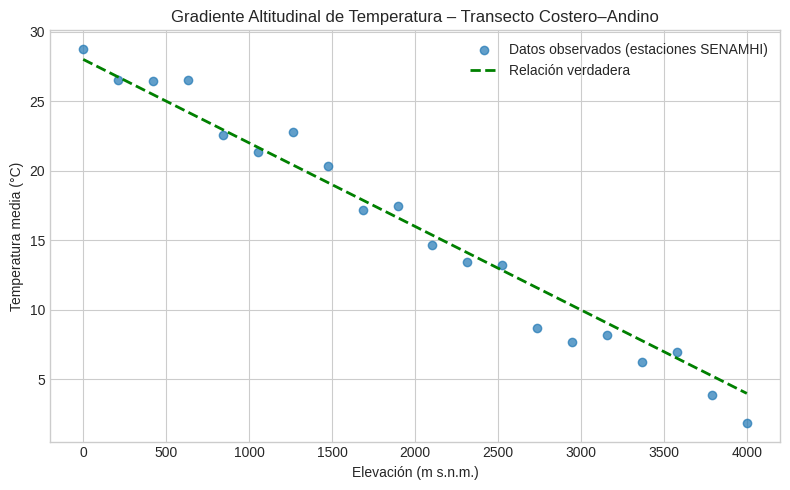

In [ ]:
# Ejemplo: ajustar una relación lineal entre elevación y temperatura
# Gradiente ambiental real: temperatura disminuye ~0.6°C por cada 100 m de altitud
np.random.seed(42)

elevacion_m  = np.linspace(0, 4000, 20)   # Gradiente costero–andino (m)
temp_verdadera = 28 - 0.006 * elevacion_m  # Relación verdadera (°C)
# Agregar ruido observacional
temp_observada = temp_verdadera + np.random.normal(0, 1.5, len(elevacion_m))

plt.figure(figsize=(8, 5))
plt.scatter(elevacion_m, temp_observada, label='Datos observados (estaciones SENAMHI)', alpha=0.7)
plt.plot(elevacion_m, temp_verdadera, 'g--', label='Relación verdadera', linewidth=2)
plt.xlabel('Elevación (m s.n.m.)')
plt.ylabel('Temperatura media (°C)')
plt.title('Gradiente Altitudinal de Temperatura – Transecto Costero–Andino')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Definir una función de costo (Error Cuadrático Medio)
def costo_ecm(params, x, y_observado):
    """
    Calcular ECM para un modelo lineal T = a + b * Elevación

    Args:
        params:       [a, b] – intercepto y pendiente
        x:            datos de elevación
        y_observado:  temperaturas observadas

    Returns:
        Error cuadrático medio
    """
    a, b = params
    y_predicho = a + b * x
    ecm = np.mean((y_observado - y_predicho) ** 2)
    return ecm

# Probar con distintas estimaciones de parámetros
print(f"ECM con a=28, b=0 (sin gradiente):           {costo_ecm([28, 0], elevacion_m, temp_observada):.2f}")
print(f"ECM con a=28, b=-0.006 (gradiente real):     {costo_ecm([28, -0.006], elevacion_m, temp_observada):.2f}")
print(f"ECM con a=25, b=-0.005 (mala estimación):    {costo_ecm([25, -0.005], elevacion_m, temp_observada):.2f}")

ECM con a=28, b=0 (sin gradiente):           217.80
ECM con a=28, b=-0.006 (gradiente real):     2.04
ECM con a=25, b=-0.005 (mala estimación):    6.09


### 4.2 Minimizando la función de costo con `scipy.optimize.minimize`

In [ ]:
# Usar scipy.optimize.minimize para encontrar los mejores parámetros
from scipy.optimize import minimize

# Estimación inicial de parámetros [a, b]
estimacion_inicial = [20, 0]

# Minimizar la función de costo
resultado = minimize(
    fun   = costo_ecm,                              # Función a minimizar
    x0    = estimacion_inicial,                     # Punto de partida
    args  = (elevacion_m, temp_observada),          # Argumentos adicionales
    method= 'Nelder-Mead'                           # Algoritmo de optimización
)

print("Resultado de la Optimización:")
print(f"  Éxito:                {resultado.success}")
print(f"  Intercepto óptimo a:  {resultado.x[0]:.4f} °C")
print(f"  Pendiente óptima b:   {resultado.x[1]:.6f} °C/m")
print(f"  Gradiente en °C/100m: {resultado.x[1]*100:.4f}")
print(f"  ECM mínimo:           {resultado.fun:.4f}")
print(f"  Iteraciones:          {resultado.nit}")

Resultado de la Optimización:
  Éxito:                True
  Intercepto óptimo a:  29.1618 °C
  Pendiente óptima b:   -0.006709 °C/m
  Gradiente en °C/100m: -0.6709
  ECM mínimo:           1.2284
  Iteraciones:          48


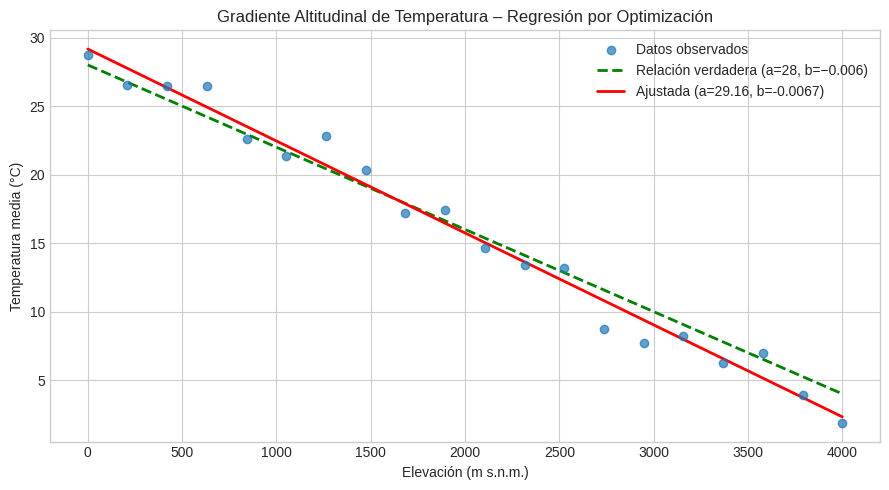

In [ ]:
# Visualizar la línea ajustada
a_opt, b_opt = resultado.x
temp_ajustada = a_opt + b_opt * elevacion_m

plt.figure(figsize=(9, 5))
plt.scatter(elevacion_m, temp_observada, label='Datos observados', alpha=0.7, zorder=5)
plt.plot(elevacion_m, temp_verdadera, 'g--', linewidth=2,
         label='Relación verdadera (a=28, b=−0.006)')
plt.plot(elevacion_m, temp_ajustada, 'r-', linewidth=2,
         label=f'Ajustada (a={a_opt:.2f}, b={b_opt:.4f})')
plt.xlabel('Elevación (m s.n.m.)')
plt.ylabel('Temperatura media (°C)')
plt.title('Gradiente Altitudinal de Temperatura – Regresión por Optimización')
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Ejemplo ambiental: Ajuste de curva de crecimiento logístico

Muchos procesos ecológicos siguen relaciones no lineales. Ajustemos un **modelo de crecimiento logístico** a datos de población de la **vicuña** (*Vicugna vicugna*) en la Reserva Nacional de Pampa Galeras (Ayacucho), que se recuperó luego de protección estricta:

$$N(t) = \frac{K}{1 + \left(\frac{K - N_0}{N_0}\right) e^{-rt}}$$

Donde:
- $K$ = capacidad de carga
- $r$ = tasa de crecimiento intrínseca
- $N_0$ = población inicial

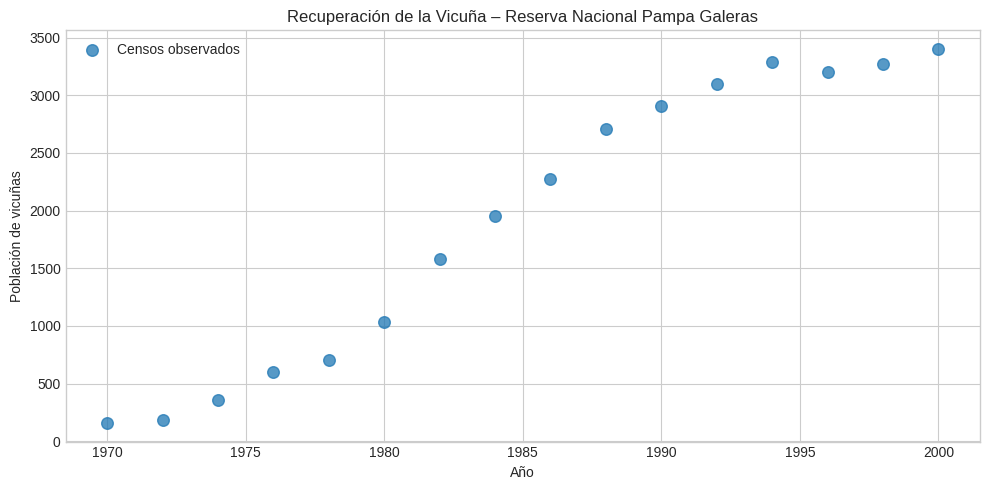

In [ ]:
# Generar datos sintéticos de recuperación de vicuñas en Pampa Galeras
np.random.seed(42)

# Parámetros verdaderos (inspirados en datos históricos)
K_verdadero  = 3500    # Capacidad de carga (vicuñas)
r_verdadero  = 0.25    # Tasa de crecimiento anual
N0_verdadero = 120     # Población inicial (1970, post-caza furtiva)

# Puntos temporales (años desde 1970)
t_datos = np.arange(0, 32, 2)  # 1970–2002

# Modelo logístico
def crecimiento_logistico(t, K, r, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# Generar datos con ruido observacional
N_verdadero  = crecimiento_logistico(t_datos, K_verdadero, r_verdadero, N0_verdadero)
N_observado  = N_verdadero + np.random.normal(0, 80, len(t_datos))
N_observado  = np.maximum(N_observado, 1)  # Asegurar valores positivos

anios = 1970 + t_datos

plt.figure(figsize=(10, 5))
plt.scatter(anios, N_observado, s=70, label='Censos observados', alpha=0.75, zorder=5)
plt.xlabel('Año')
plt.ylabel('Población de vicuñas')
plt.title('Recuperación de la Vicuña – Reserva Nacional Pampa Galeras')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Definir función de costo para el modelo logístico
def costo_logistico(params, t, N_obs):
    K, r, N0 = params

    # Prevenir valores de parámetros inválidos
    if K <= 0 or r <= 0 or N0 <= 0 or N0 >= K:
        return 1e10  # Valor grande para parámetros inválidos

    N_pred = crecimiento_logistico(t, K, r, N0)
    ecm = np.mean((N_obs - N_pred) ** 2)
    return ecm

# Estimaciones iniciales de los parámetros
params_iniciales = [2000, 0.1, 50]  # [K, r, N0]

# Optimizar
resultado = minimize(
    fun    = costo_logistico,
    x0     = params_iniciales,
    args   = (t_datos, N_observado),
    method = 'Nelder-Mead'
)

K_aj, r_aj, N0_aj = resultado.x

print("Parámetros Ajustados – Recuperación de Vicuña:")
print(f"  Capacidad de carga K:     {K_aj:.0f}  (real: {K_verdadero})")
print(f"  Tasa de crecimiento r:    {r_aj:.3f}  (real: {r_verdadero})")
print(f"  Población inicial N0:     {N0_aj:.0f}  (real: {N0_verdadero})")
print(f"\n  ECM final: {resultado.fun:.1f}")

Parámetros Ajustados – Recuperación de Vicuña:
  Capacidad de carga K:     3405  (real: 3500)
  Tasa de crecimiento r:    0.251  (real: 0.25)
  Población inicial N0:     130  (real: 120)

  ECM final: 3056.0


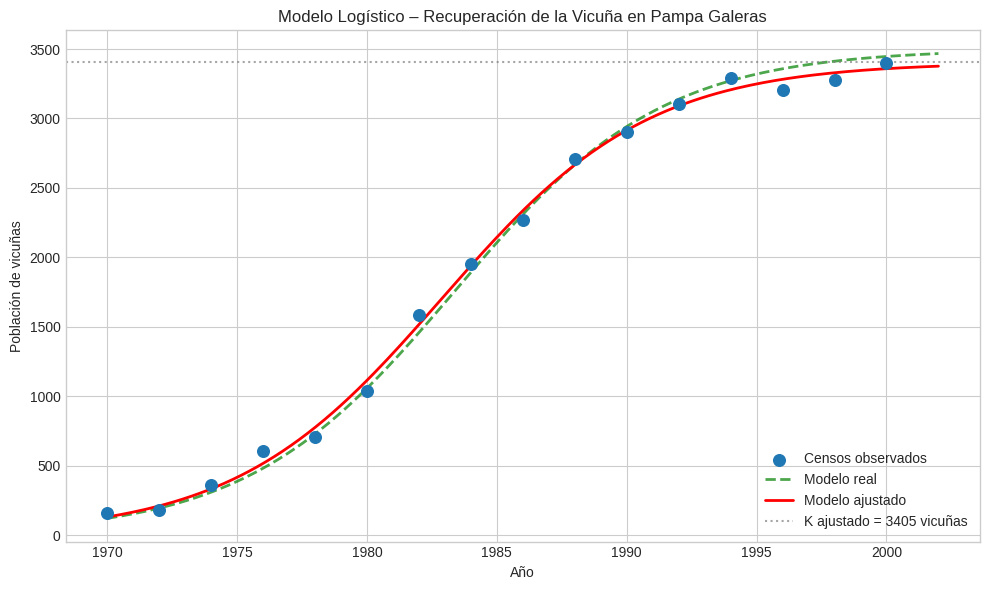

In [ ]:
# Visualizar el ajuste
t_suave  = np.linspace(0, 32, 200)
N_ajuste = crecimiento_logistico(t_suave, K_aj, r_aj, N0_aj)
N_real   = crecimiento_logistico(t_suave, K_verdadero, r_verdadero, N0_verdadero)
anios_suave = 1970 + t_suave

plt.figure(figsize=(10, 6))
plt.scatter(anios, N_observado, s=70, label='Censos observados', zorder=5)
plt.plot(anios_suave, N_real,   'g--', linewidth=2, label='Modelo real', alpha=0.7)
plt.plot(anios_suave, N_ajuste, 'r-',  linewidth=2, label='Modelo ajustado')
plt.axhline(y=K_aj, color='gray', linestyle=':', alpha=0.7,
            label=f'K ajustado = {K_aj:.0f} vicuñas')
plt.xlabel('Año')
plt.ylabel('Población de vicuñas')
plt.title('Modelo Logístico – Recuperación de la Vicuña en Pampa Galeras')
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Usando `curve_fit` para un ajuste más sencillo

In [ ]:
from scipy.optimize import curve_fit

# curve_fit espera la firma: f(x, param1, param2, ...)
# Nuestra función crecimiento_logistico ya tiene esta forma

# Estimaciones iniciales y límites
p0 = [2000, 0.1, 50]                           # [K, r, N0]
limites = ([500, 0.01, 1], [6000, 1.0, 500])   # [inf, sup]

# Ajustar el modelo
popt, pcov = curve_fit(crecimiento_logistico, t_datos, N_observado,
                        p0=p0, bounds=limites)

K_cf, r_cf, N0_cf = popt

# Calcular errores estándar a partir de la matriz de covarianza
errores = np.sqrt(np.diag(pcov))

print("Resultados de curve_fit – Vicuña en Pampa Galeras:")
print(f"  K  = {K_cf:.0f}  ± {errores[0]:.0f}  vicuñas")
print(f"  r  = {r_cf:.3f} ± {errores[1]:.3f}")
print(f"  N0 = {N0_cf:.0f}  ± {errores[2]:.0f}  vicuñas")
print()
print("curve_fit es más conveniente y además estima la incertidumbre de los parámetros.")

Resultados de curve_fit – Vicuña en Pampa Galeras:
  K  = 3405  ± 40  vicuñas
  r  = 0.251 ± 0.009
  N0 = 130  ± 14  vicuñas

curve_fit es más conveniente y además estima la incertidumbre de los parámetros.


### 4.5 Métodos de optimización

Distintos algoritmos son adecuados para distintos problemas:

| Método | Cuándo usarlo |
|--------|---------------|
| `Nelder-Mead` | Propósito general, no requiere gradientes |
| `BFGS` | Funciones suaves, usa gradientes |
| `L-BFGS-B` | Optimización con límites |
| `Powell` | Funciones no suaves |
| `differential_evolution` | Optimización global (evita mínimos locales) |

In [ ]:
# Ejemplo con límites usando L-BFGS-B
from scipy.optimize import minimize

resultado_limitado = minimize(
    fun     = costo_logistico,
    x0      = [2000, 0.1, 50],
    args    = (t_datos, N_observado),
    method  = 'L-BFGS-B',
    bounds  = [(500, 6000), (0.01, 1.0), (1, 500)]  # Límites por parámetro
)

print(f"Resultado con L-BFGS-B:")
K_lb, r_lb, N0_lb = resultado_limitado.x
print(f"  K = {K_lb:.0f}, r = {r_lb:.3f}, N0 = {N0_lb:.0f}")
print(f"  Convergió: {resultado_limitado.success}")

Resultado con L-BFGS-B:
  K = 3405, r = 0.251, N0 = 130
  Convergió: True


### 🔬 Ejercicio rápido 4 – Ajuste de modelo de temperatura

El SENAMHI registra la temperatura máxima mensual en Cusco (°C):

```python
mes       = np.arange(1, 13)   # Enero a Diciembre
temp_max  = np.array([19.2, 19.5, 19.1, 18.8, 18.2, 17.5, 17.2, 18.0, 18.9, 19.8, 20.1, 19.5])
```

La temperatura sigue un patrón estacional que puede modelarse con una función sinusoidal:

$$T(m) = A \cdot \sin\left(\frac{2\pi}{12}(m - \phi)\right) + C$$

Donde $A$ es la amplitud, $\phi$ el desfase y $C$ la media anual.

1. Define la función sinusoidal
2. Usa `curve_fit` para ajustar el modelo a los datos
3. Visualiza los datos y el modelo ajustado
4. ¿Cuál es la amplitud estacional y la temperatura media anual según el modelo?

In [ ]:
# Tu código aquí
mes      = np.arange(1, 13)
temp_max = np.array([19.2, 19.5, 19.1, 18.8, 18.2, 17.5, 17.2, 18.0, 18.9, 19.8, 20.1, 19.5])

def modelo_sinusoidal(m, A, phi, C):
    """Modelo sinusoidal de temperatura estacional."""
    # return A * np.sin(2 * np.pi / 12 * (m - phi)) + C
    pass

# popt, pcov = curve_fit(???)
# A_aj, phi_aj, C_aj = popt

### 🔬 Ejercicio rápido 5 – Ecuación de Michaelis-Menten (absorción de nutrientes)

La **ecuación de Michaelis-Menten** describe la tasa de absorción de nutrientes por fitoplancton en el Lago Titicaca:

$$V = \frac{V_{\max} \cdot S}{K_m + S}$$

Donde:
- $V$ = tasa de absorción (μmol/L·h)
- $V_{\max}$ = tasa máxima de absorción
- $S$ = concentración de sustrato (μmol/L)
- $K_m$ = constante de semi-saturación

Ajusta este modelo a los datos experimentales:

In [ ]:
# Datos de absorción de nitratos por fitoplancton en el Lago Titicaca
sustrato = np.array([0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0])  # μmol/L
tasa     = np.array([1.8, 3.2, 5.5, 9.2, 12.8, 15.5, 17.8, 18.5])   # μmol/L·h

# 1. Define la función de Michaelis-Menten
def michaelis_menten(S, Vmax, Km):
    # Tu código aquí
    pass

# 2. Usa curve_fit para encontrar los parámetros óptimos
# popt, pcov = curve_fit(???)
# Vmax_aj, Km_aj = popt

# 3. Visualiza los datos y el modelo ajustado

# 4. Interpreta:
# ¿A qué concentración se alcanza la mitad de Vmax?  → es Km
# ¿Cuál es la tasa máxima de absorción?               → es Vmax

---
## Resumen

**Conceptos clave de hoy:**

1. **Distribuciones SciPy**: `pdf`, `cdf`, `ppf`, `fit`, `rvs`
2. **Pruebas de hipótesis**:
   - Una muestra: `stats.ttest_1samp()`
   - Dos muestras: `stats.ttest_ind()`
   - Correlación: `stats.pearsonr()`, `stats.spearmanr()`
   - No paramétricas: `stats.mannwhitneyu()`, `stats.shapiro()`
3. **Optimización**:
   - Definir una función de costo que mida el error del modelo
   - Usar `scipy.optimize.minimize()` para encontrar parámetros óptimos
   - Usar `scipy.optimize.curve_fit()` para ajuste conveniente con estimación de incertidumbre

**El flujo de trabajo de optimización:**
1. Definir la función del modelo
2. Definir una función de costo (ej. ECM)
3. Elegir estimaciones iniciales de parámetros
4. Llamar al optimizador
5. Evaluar y visualizar resultados

**Aplicaciones en el contexto peruano:**
- Ajuste de distribuciones al DAP de inventarios forestales del **SERFOR**
- Pruebas de hipótesis para calidad del agua según **ECA-MINAM**
- Modelos de recuperación de fauna silvestre (**SERNANP** – vicuñas en Pampa Galeras)
- Gradientes altitudinales de temperatura (**SENAMHI**)
- Absorción de nutrientes en el **Lago Titicaca** (**INAIGEM**)

---
## Soluciones a los ejercicios

In [ ]:
# Solución Ejercicio rápido 1 – Distribuciones
dist_precip = stats.norm(loc=2890, scale=210)

prob_seco       = dist_precip.cdf(2500)
umbral_sequia   = dist_precip.ppf(0.10)
limite_inf_80   = dist_precip.ppf(0.10)
limite_sup_80   = dist_precip.ppf(0.90)

print("Precipitación anual en Iquitos – Análisis estadístico")
print(f"  P(precip < 2500 mm):  {prob_seco:.4f}  ({prob_seco*100:.2f}%)")
print(f"  Umbral de sequía (P10): {umbral_sequia:.0f} mm")
print(f"  Rango del 80% central:  {limite_inf_80:.0f} – {limite_sup_80:.0f} mm")

Precipitación anual en Iquitos – Análisis estadístico
  P(precip < 2500 mm):  0.0316  (3.16%)
  Umbral de sequía (P10): 2621 mm
  Rango del 80% central:  2621 – 3159 mm


In [ ]:
# Solución Ejercicio rápido 2 – Prueba t cuencas andinas
ph_mantaro = np.array([6.8, 7.2, 6.5, 7.0, 6.9, 7.3, 6.7, 7.1])
ph_rimac   = np.array([6.1, 5.9, 6.4, 6.0, 6.3, 5.8, 6.2, 6.1])

# ① Prueba t de una muestra (Rímac vs ECA mínimo de 6.5)
t1, p1 = stats.ttest_1samp(ph_rimac, popmean=6.5, alternative='less')
print(f"Rímac vs ECA (pH=6.5):  t={t1:.3f}, p={p1:.4f}")
print("  → El pH del Rímac es significativamente MENOR que 6.5" if p1 < 0.05
      else "  → Sin evidencia de incumplimiento del ECA")

# ② Prueba t de dos muestras
t2, p2 = stats.ttest_ind(ph_mantaro, ph_rimac)
print(f"\nMantaro vs Rímac:  t={t2:.3f}, p={p2:.4f}")
print(f"  Media Mantaro: {ph_mantaro.mean():.2f}")
print(f"  Media Rímac:   {ph_rimac.mean():.2f}")
print("  → Diferencia significativa entre cuencas" if p2 < 0.05
      else "  → Sin diferencia significativa")

Rímac vs ECA (pH=6.5):  t=-5.657, p=0.0004
  → El pH del Rímac es significativamente MENOR que 6.5

Mantaro vs Rímac:  t=7.102, p=0.0000
  Media Mantaro: 6.94
  Media Rímac:   6.10
  → Diferencia significativa entre cuencas


Pearson  r = 0.985  (p = 0.0000)
Spearman ρ = 1.000  (p = 0.0000)
La precipitación explica el 97.1% de la varianza del NDVI


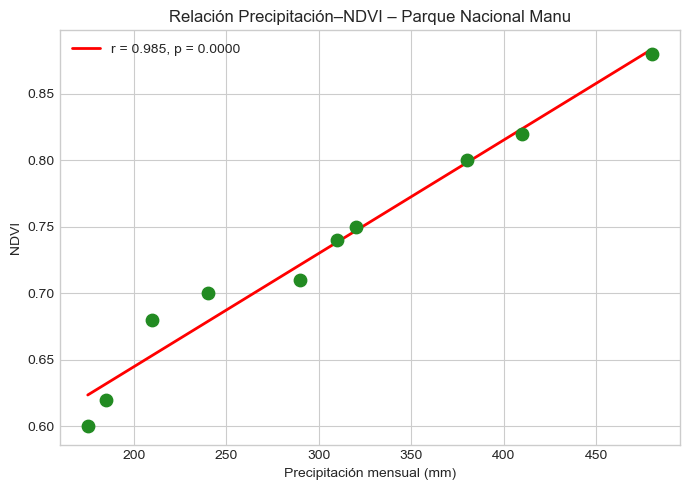

In [ ]:
# Solución Ejercicio rápido 3 – Correlación NDVI-Precipitación
precip_mm = np.array([185, 210, 320, 410, 480, 290, 175, 240, 380, 310])
ndvi      = np.array([0.62, 0.68, 0.75, 0.82, 0.88, 0.71, 0.60, 0.70, 0.80, 0.74])

r_pearson,  p_pearson  = stats.pearsonr(precip_mm, ndvi)
rho_spearman, p_spear  = stats.spearmanr(precip_mm, ndvi)

print(f"Pearson  r = {r_pearson:.3f}  (p = {p_pearson:.4f})")
print(f"Spearman ρ = {rho_spearman:.3f}  (p = {p_spear:.4f})")
print(f"La precipitación explica el {r_pearson**2*100:.1f}% de la varianza del NDVI")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(precip_mm, ndvi, s=80, color='forestgreen', zorder=5)
m, b, *_ = stats.linregress(precip_mm, ndvi)
x_l = np.array([precip_mm.min(), precip_mm.max()])
ax.plot(x_l, m*x_l + b, 'r-', linewidth=2,
        label=f'r = {r_pearson:.3f}, p = {p_pearson:.4f}')
ax.set_xlabel('Precipitación mensual (mm)')
ax.set_ylabel('NDVI')
ax.set_title('Relación Precipitación–NDVI – Parque Nacional Manu')
ax.legend()
plt.tight_layout()
plt.show()

Amplitud estacional A = -1.11 ± 0.18 °C
Desfase φ             = 3.20 ± 0.31 meses
Temperatura media C   = 18.82 ± 0.13 °C


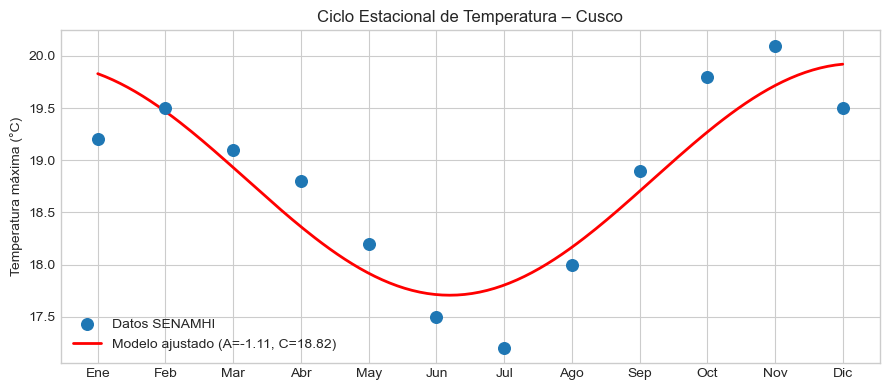

In [ ]:
# Solución Ejercicio rápido 4 – Temperatura estacional en Cusco
mes      = np.arange(1, 13)
temp_max = np.array([19.2, 19.5, 19.1, 18.8, 18.2, 17.5, 17.2, 18.0, 18.9, 19.8, 20.1, 19.5])

def modelo_sinusoidal(m, A, phi, C):
    "Temperatura estacional sinusoidal."
    return A * np.sin(2 * np.pi / 12 * (m - phi)) + C

popt, pcov = curve_fit(modelo_sinusoidal, mes, temp_max, p0=[1.5, 3, 19])
A_aj, phi_aj, C_aj = popt
err = np.sqrt(np.diag(pcov))

print(f"Amplitud estacional A = {A_aj:.2f} ± {err[0]:.2f} °C")
print(f"Desfase φ             = {phi_aj:.2f} ± {err[1]:.2f} meses")
print(f"Temperatura media C   = {C_aj:.2f} ± {err[2]:.2f} °C")

mes_suave = np.linspace(1, 12, 200)
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(mes, temp_max, s=70, zorder=5, label='Datos SENAMHI')
ax.plot(mes_suave, modelo_sinusoidal(mes_suave, *popt), 'r-', linewidth=2,
        label=f'Modelo ajustado (A={A_aj:.2f}, C={C_aj:.2f})')
ax.set_xticks(mes)
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_ylabel('Temperatura máxima (°C)')
ax.set_title('Ciclo Estacional de Temperatura – Cusco')
ax.legend()
plt.tight_layout()
plt.show()

Vmax = 19.57 ± 0.13 μmol/L·h  (tasa máxima de absorción)
Km   = 5.32  ± 0.14 μmol/L    (constante de semi-saturación)


C:\Users\cmillan\AppData\Local\Temp\ipykernel_28788\483347853.py:29: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\cmillan\AppData\Local\Temp\ipykernel_28788\483347853.py:29: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\ProgramData\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


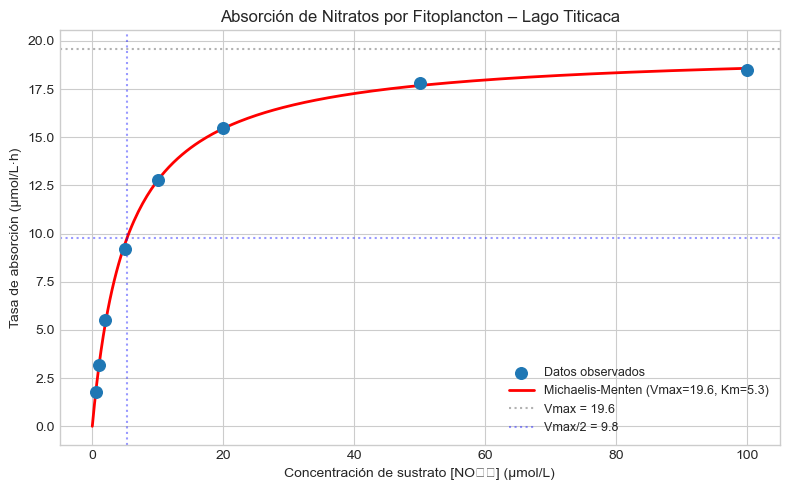

In [ ]:
# Solución Ejercicio rápido 5 – Michaelis-Menten en el Titicaca
sustrato = np.array([0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0])
tasa     = np.array([1.8, 3.2, 5.5, 9.2, 12.8, 15.5, 17.8, 18.5])

def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

popt, pcov = curve_fit(michaelis_menten, sustrato, tasa, p0=[20, 5])
Vmax_aj, Km_aj = popt
err_mm = np.sqrt(np.diag(pcov))

print(f"Vmax = {Vmax_aj:.2f} ± {err_mm[0]:.2f} μmol/L·h  (tasa máxima de absorción)")
print(f"Km   = {Km_aj:.2f}  ± {err_mm[1]:.2f} μmol/L    (constante de semi-saturación)")

S_suave   = np.linspace(0, 100, 300)
V_ajuste  = michaelis_menten(S_suave, Vmax_aj, Km_aj)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sustrato, tasa, s=70, zorder=5, label='Datos observados')
ax.plot(S_suave, V_ajuste, 'r-', linewidth=2,
        label=f'Michaelis-Menten (Vmax={Vmax_aj:.1f}, Km={Km_aj:.1f})')
ax.axhline(y=Vmax_aj,    color='gray', linestyle=':', alpha=0.6, label=f'Vmax = {Vmax_aj:.1f}')
ax.axhline(y=Vmax_aj/2,  color='blue', linestyle=':', alpha=0.4, label=f'Vmax/2 = {Vmax_aj/2:.1f}')
ax.axvline(x=Km_aj,      color='blue', linestyle=':', alpha=0.4)
ax.set_xlabel('Concentración de sustrato [NO₃⁻] (μmol/L)')
ax.set_ylabel('Tasa de absorción (μmol/L·h)')
ax.set_title('Absorción de Nitratos por Fitoplancton – Lago Titicaca')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()